---
source: ⚠️ Jupyter Notebook
title: Trace Snowflake Cortex REST API Calls with Langfuse
description: Learn how to use the Langfuse OpenAI SDK wrapper to trace Snowflake Cortex REST API calls. Snowflake Cortex provides an OpenAI-compatible REST API for models from Anthropic (Claude), OpenAI (GPT), Meta (Llama), Mistral, DeepSeek, and Snowflake.
category: Integrations
---

# Cookbook: Trace Snowflake Cortex REST API Calls with Langfuse

[Snowflake Cortex](https://docs.snowflake.com/en/user-guide/snowflake-cortex/cortex-rest-api) provides a fully managed, OpenAI-compatible REST API for running large language models from **Anthropic** (Claude), **OpenAI** (GPT), **Meta** (Llama), **Mistral**, **DeepSeek**, and **Snowflake** directly within your Snowflake account. Since it is OpenAI-compatible, you can use the [Langfuse OpenAI SDK wrapper](https://langfuse.com/integrations/model-providers/openai-py) to automatically trace all Cortex REST API calls.

In this cookbook, you'll learn how to:

1. Set up the Langfuse OpenAI wrapper pointed at Snowflake Cortex
2. Make traced chat completion requests
3. Use `@observe()` to create nested traces for multi-step pipelines

> **What is Snowflake Cortex?** [Snowflake Cortex](https://docs.snowflake.com/en/user-guide/snowflake-cortex/cortex-rest-api) provides serverless access to industry-leading LLMs from Anthropic, OpenAI, Meta, Mistral, DeepSeek, and Snowflake through an OpenAI-compatible API. All inference runs within your Snowflake account — your data never leaves Snowflake's security perimeter.

> **What is Langfuse?** [Langfuse](https://langfuse.com/) is an open source LLM engineering platform that helps teams trace LLM calls, monitor performance, and debug issues in their AI applications.

<div class="alert alert-block alert-info">
<b>Note:</b> Langfuse is also natively integrated with <a href="https://langfuse.com/integrations/frameworks/langchain">LangChain</a>, <a href="https://langfuse.com/integrations/frameworks/llamaindex">LlamaIndex</a>, <a href="https://langfuse.com/integrations/gateways/litellm">LiteLLM</a>, and <a href="https://langfuse.com/integrations">other frameworks</a>. If you use one of them, any use of Snowflake Cortex models is instrumented right away.
</div>

## Setup

### Prerequisites

- A [Snowflake account](https://signup.snowflake.com/) with Cortex LLM access enabled
- A Snowflake [Programmatic Access Token (PAT)](https://docs.snowflake.com/en/user-guide/programmatic-access-tokens) or key-pair authentication
- A [Langfuse](https://cloud.langfuse.com) project with API keys

### Install Required Packages

In [ ]:
%pip install langfuse openai --upgrade

### Set Environment Variables

Configure your Langfuse and Snowflake credentials. Get your Langfuse keys from the [project settings page](https://cloud.langfuse.com).

In [ ]:
import os

os.environ["LANGFUSE_PUBLIC_KEY"] = "pk-lf-..."
os.environ["LANGFUSE_SECRET_KEY"] = "sk-lf-..."
os.environ["LANGFUSE_BASE_URL"] = "https://cloud.langfuse.com"  # 🇪🇺 EU region
# os.environ["LANGFUSE_BASE_URL"] = "https://us.cloud.langfuse.com"  # 🇺🇸 US region

SNOWFLAKE_ACCOUNT = "<your-snowflake-account>"  # e.g. "myorg-myaccount"
SNOWFLAKE_PAT = "<your-programmatic-access-token>"

### Verify Langfuse Connection

In [ ]:
from langfuse import get_client

langfuse = get_client()
assert langfuse.auth_check(), "Langfuse auth failed - check your keys ✋"

## Example 1: Simple Chat Completion

Since Snowflake Cortex provides an OpenAI-compatible API, we use the [Langfuse OpenAI SDK wrapper](https://langfuse.com/integrations/model-providers/openai-py) to automatically log all calls as generations in Langfuse.

- The `base_url` points to Snowflake Cortex's OpenAI-compatible endpoint (`/api/v2/cortex/v1`)
- The `api_key` is your Snowflake Programmatic Access Token (PAT)
- You can use any [Cortex-supported model](https://docs.snowflake.com/en/user-guide/snowflake-cortex/cortex-rest-api) — **Anthropic** (Claude), **OpenAI** (GPT), Meta (Llama), Mistral, DeepSeek, or Snowflake models

In [ ]:
from langfuse.openai import OpenAI

client = OpenAI(
    base_url=f"https://{SNOWFLAKE_ACCOUNT}.snowflakecomputing.com/api/v2/cortex/v1",
    api_key=SNOWFLAKE_PAT,
)

In [ ]:
completion = client.chat.completions.create(
    model="claude-sonnet-4-5",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "What is Snowflake Cortex? Answer in 2-3 sentences."},
    ],
    name="cortex-simple-call",
)
print(completion.choices[0].message.content)

After running the cell above, you'll see the trace appear in your [Langfuse dashboard](https://cloud.langfuse.com) with the request parameters, response content, and latency metrics.

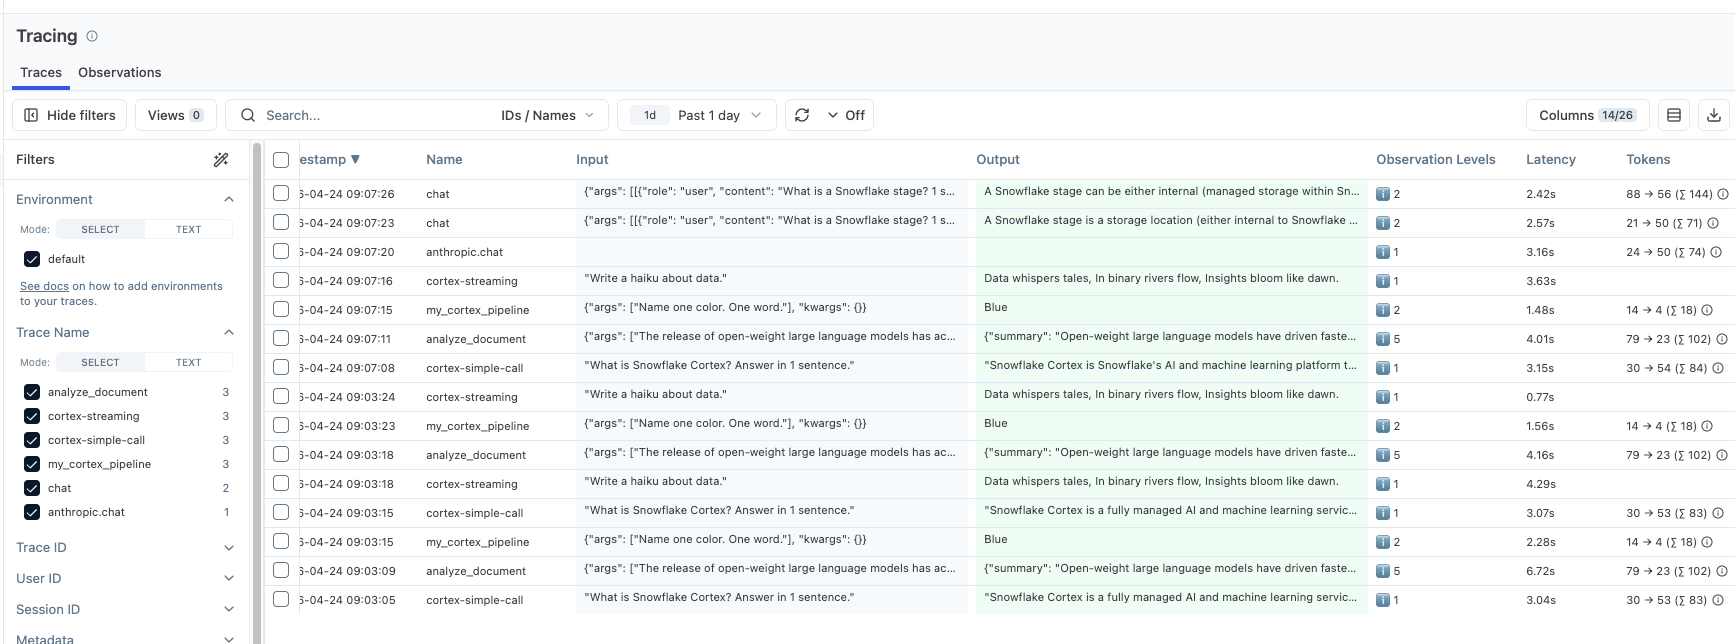


## Example 2: Nested LLM Calls with `@observe()`

By using the [`@observe()` decorator](https://langfuse.com/docs/observability/sdk/instrumentation#custom-instrumentation), you can capture execution details of any Python function, including nested LLM calls, inputs, outputs, and execution times. This provides in-depth observability with minimal code changes.

- The `@observe()` decorator captures inputs, outputs, and execution details of each function
- Nested functions create a hierarchy of traces
- Each LLM call within the functions is logged, providing a detailed trace of the execution flow

In [ ]:
from langfuse import observe
from langfuse.openai import OpenAI

client = OpenAI(
    base_url=f"https://{SNOWFLAKE_ACCOUNT}.snowflakecomputing.com/api/v2/cortex/v1",
    api_key=SNOWFLAKE_PAT,
)


@observe()
def summarize(text: str) -> str:
    response = client.chat.completions.create(
        model="claude-sonnet-4-5",
        messages=[
            {"role": "user", "content": f"Summarize in 2-3 sentences:\n\n{text}"},
        ],
        name="summarize",
    )
    return response.choices[0].message.content


@observe()
def classify_sentiment(text: str) -> str:
    response = client.chat.completions.create(
        model="claude-sonnet-4-5",
        messages=[
            {
                "role": "user",
                "content": f"Classify the sentiment as POSITIVE, NEGATIVE, or NEUTRAL. Respond with just the label.\n\n{text}",
            },
        ],
        name="classify-sentiment",
    )
    return response.choices[0].message.content


@observe()
def analyze_document(doc: str) -> dict:
    summary = summarize(doc)
    sentiment = classify_sentiment(doc)
    return {"summary": summary, "sentiment": sentiment}

In [ ]:
result = analyze_document(
    "The release of open-weight large language models has accelerated innovation "
    "across the AI industry. Researchers can now fine-tune powerful models on "
    "domain-specific data without relying solely on proprietary APIs, lowering "
    "the barrier to entry for startups and academic labs alike."
)

print(f"Summary:   {result['summary']}")
print(f"Sentiment: {result['sentiment']}")

The trace in Langfuse shows the full execution hierarchy:

- `analyze_document` (parent span)
  - `summarize` (child span + generation)
  - `classify_sentiment` (child span + generation)

## Example 3: Adding Custom Metadata

Use `propagate_attributes` to attach user IDs, session IDs, tags, and metadata to all spans created within an execution scope.

In [ ]:
from langfuse import observe, propagate_attributes, get_client

langfuse = get_client()


@observe()
def my_cortex_pipeline(user_input: str):
    with propagate_attributes(
        user_id="user_123",
        session_id="session_abc",
        tags=["cortex", "production"],
        metadata={"snowflake_account": SNOWFLAKE_ACCOUNT},
    ):
        response = client.chat.completions.create(
            model="claude-sonnet-4-5",
            messages=[{"role": "user", "content": user_input}],
            name="cortex-with-metadata",
        )
        return response.choices[0].message.content


result = my_cortex_pipeline("What are the benefits of running LLMs inside Snowflake?")
print(result)

## Example 4: Streaming Responses

Snowflake Cortex supports streaming. The Langfuse wrapper automatically captures the full streamed response.

In [ ]:
stream = client.chat.completions.create(
    model="mistral-large2",
    messages=[
        {"role": "user", "content": "Write a haiku about data warehousing."},
    ],
    stream=True,
    name="cortex-streaming",
)

for chunk in stream:
    if chunk.choices[0].delta.content:
        print(chunk.choices[0].delta.content, end="", flush=True)

print()

## Messages API

The Messages API follows the Anthropic specification and supports **Claude models only**. Use the [AnthropicInstrumentor](https://pypi.org/project/opentelemetry-instrumentation-anthropic/) to automatically send OpenTelemetry spans to Langfuse.

The Anthropic SDK sends credentials via `x-api-key` by default, but Snowflake expects a `Bearer` token. Use an `httpx` client to override the authorization header.

In [ ]:
%pip install anthropic httpx opentelemetry-instrumentation-anthropic --upgrade

### Example 5: Simple Messages Call

In [ ]:
from opentelemetry.instrumentation.anthropic import AnthropicInstrumentor
AnthropicInstrumentor().instrument()

import httpx
from anthropic import Anthropic

http_client = httpx.Client(
    headers={"Authorization": f"Bearer {SNOWFLAKE_PAT}"},
)

anthropic_client = Anthropic(
    api_key="not-used",
    base_url=f"https://{SNOWFLAKE_ACCOUNT}.snowflakecomputing.com/api/v2/cortex",
    http_client=http_client,
    default_headers={"Authorization": f"Bearer {SNOWFLAKE_PAT}"},
)

response = anthropic_client.messages.create(
    model="claude-sonnet-4-5",
    max_tokens=1024,
    messages=[
        {"role": "user", "content": "What is Snowflake Cortex? Answer in 2-3 sentences."},
    ],
)
print(response.content[0].text)

### Example 6: Multi-turn Conversation

In [ ]:
from langfuse import observe

@observe()
def chat(conversation: list) -> str:
    response = anthropic_client.messages.create(
        model="claude-sonnet-4-5",
        max_tokens=1024,
        system="You are a helpful data engineering assistant.",
        messages=conversation,
    )
    return response.content[0].text

history = []
for user_msg in [
    "What is a Snowflake stage?",
    "How does it differ from an external stage?",
]:
    history.append({"role": "user", "content": user_msg})
    reply = chat(history)
    history.append({"role": "assistant", "content": reply})
    print(f"User: {user_msg}")
    print(f"Assistant: {reply}\n")

### Available Cortex Models

Snowflake Cortex provides access to models from **Anthropic** (Claude), **OpenAI** (GPT), **Meta** (Llama), **Mistral**, **DeepSeek**, and **Snowflake**. Simply change the `model` parameter to any supported model.

See the full model list and region availability matrix in the [Cortex REST API docs](https://docs.snowflake.com/en/user-guide/snowflake-cortex/cortex-rest-api).

## Authentication Options

The examples above use a **Programmatic Access Token (PAT)**, the simplest approach. Snowflake Cortex also supports **Key-Pair (JWT)** and **OAuth** authentication.

For a detailed walkthrough of all three methods, see: [You Have Three Options to Authenticate to the Cortex REST API](https://medium.com/snowflake/you-have-three-options-to-authenticate-to-the-cortex-rest-api-heres-how-each-one-works-cfede8c15aec)

For the official reference, see the [Cortex REST API authentication docs](https://docs.snowflake.com/en/user-guide/snowflake-cortex/cortex-rest-api).

## See Traces in Langfuse

After running the examples, you'll see detailed traces in your Langfuse dashboard including:

- Request parameters (model, messages, temperature, etc.)
- Response content
- Latency metrics
- Nested execution hierarchy for multi-step pipelines

In [ ]:
langfuse.flush()